<a href="https://colab.research.google.com/github/antas06/DL_Scratch/blob/Root_functions/Dropout_Layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("/content/Salary Data.csv")

In [3]:
df.shape

(375, 6)

In [4]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
df["Job Title"].nunique()

174

In [6]:
df["Education Level"].nunique()

3

In [7]:
df.drop(columns =["Gender","Job Title", "Education Level", "Age"], inplace = True)

In [8]:
df.head()

,Years of Experience,Salary
0,5.0,90000.0
1,3.0,65000.0
2,15.0,150000.0
3,7.0,60000.0
4,20.0,200000.0


In [9]:
df = df.dropna(subset=["Years of Experience"])

In [10]:
df["Years of Experience"].isna().sum()

np.int64(0)

In [11]:
target = "Salary"
X = df.drop(columns = [target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
df["Salary"].isna().sum()

np.int64(0)

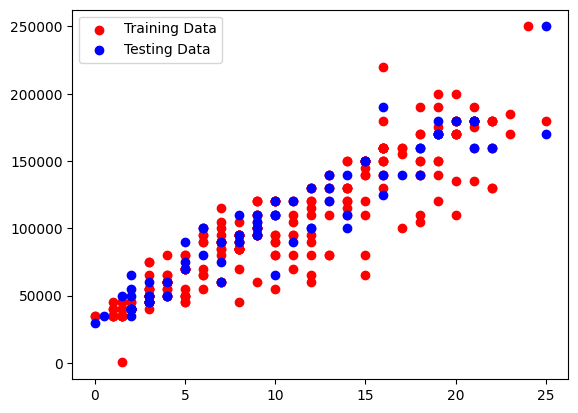

In [13]:
plt.scatter(X_train, y_train, c="red", label = "Training Data")
plt.scatter(X_test, y_test, c="blue", label = "Testing Data")
plt.legend()
plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler

X_Scaler = StandardScaler()
X_train_scaled = X_Scaler.fit_transform(X_train)
X_test_scaled = X_Scaler.transform(X_test)

y_Scaler = StandardScaler()
y_train_scaled = y_Scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_Scaler.transform(y_test.values.reshape(-1, 1))

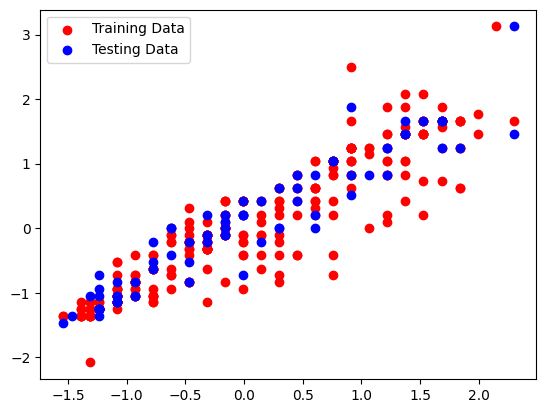

In [21]:
plt.scatter(X_train_scaled, y_train_scaled, c="red", label = "Training Data")
plt.scatter(X_test_scaled, y_test_scaled, c="blue", label = "Testing Data")
plt.legend()

In [22]:
X_train_scaled.shape

(298, 1)

In [24]:
model1= Sequential()

model1.add(Dense(128,input_dim=1, activation = "relu"))
model1.add(Dense(128, activation = "relu"))
model1.add(Dense(1, activation = "linear"))


In [25]:
adam = Adam(learning_rate=0.01)
model1.compile(optimizer=adam,loss='mse', metrics=['mse'])
history = model1.fit(X_train_scaled, y_train_scaled, epochs=500,
                    validation_data = (X_test_scaled, y_test_scaled))

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 0.4661 - mse: 0.4661 - val_loss: 0.2692 - val_mse: 0.2692
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2287 - mse: 0.2287 - val_loss: 0.1069 - val_mse: 0.1069
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1427 - mse: 0.1427 - val_loss: 0.0998 - val_mse: 0.0998
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1595 - mse: 0.1595 - val_loss: 0.1121 - val_mse: 0.1121
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1513 - mse: 0.1513 - val_loss: 0.1006 - val_mse: 0.1006
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1537 - mse: 0.1537 - val_loss: 0.1074 - val_mse: 0.1074
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1373 - mse: 0.1373 - val_loss: 0.1093 - val_mse: 0.1093
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1384 - mse: 0.1384 - val_loss: 0.1227 - val_mse: 0.1227
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - lo

In [39]:
_, mse1 = model1.evaluate(X_test_scaled, y_test_scaled)
print("MSE:", mse1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.1101 - mse: 0.1101
MSE: 0.10811204463243484


In [40]:
y_pred1 = model1.predict(X_test_scaled)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


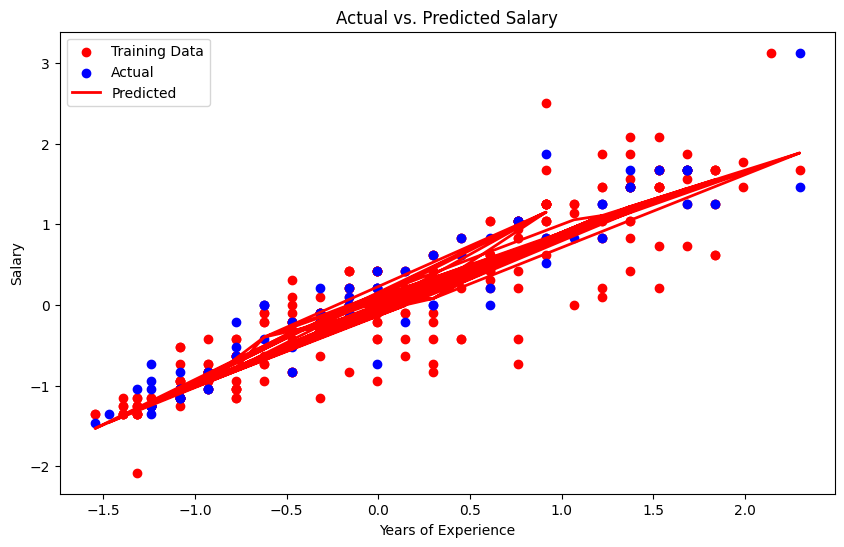

In [41]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_scaled, y_train_scaled, color='red', label='Training Data')
plt.scatter(X_test_scaled, y_test_scaled, color='blue', label='Actual')
plt.plot(X_test_scaled, y_pred1, color='red', linewidth=2, label='Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Actual vs. Predicted Salary')
plt.legend()
plt.show()

In [48]:
model2= Sequential()

model2.add(Dense(128,input_dim=1, activation = "relu"))
model2.add(Dropout(0.5))
model2.add(Dense(1, activation = "linear"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [49]:
adam = Adam(learning_rate=0.01)
model2.compile(optimizer=adam,loss='mse', metrics=['mse'])
history_model2 = model2.fit(X_train_scaled, y_train_scaled, epochs=500,
                    validation_data = (X_test_scaled, y_test_scaled))

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.6999 - mse: 0.6999 - val_loss: 0.1605 - val_mse: 0.1605
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2765 - mse: 0.2765 - val_loss: 0.1487 - val_mse: 0.1487
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2308 - mse: 0.2308 - val_loss: 0.1311 - val_mse: 0.1311
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2079 - mse: 0.2079 - val_loss: 0.1195 - val_mse: 0.1195
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1731 - mse: 0.1731 - val_loss: 0.1141 - val_mse: 0.1141
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1705 - mse: 0.1705 - val_loss: 0.1244 - val_mse: 0.1244
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1641 - mse: 0.1641 - val_loss: 0.1085 - val_mse: 0.1085
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1690 - mse: 0.1690 - val_loss: 0.1069 - val_mse: 0.1069
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - lo

In [50]:
y_pred2 = model2.predict(X_test_scaled)

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


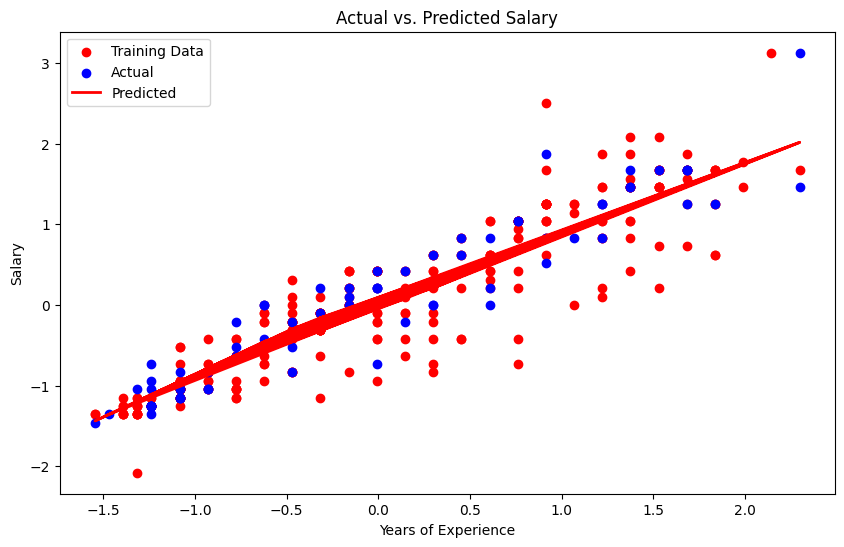

In [51]:
plt.figure(figsize=(10, 6))
plt.scatter(X_train_scaled, y_train_scaled, color='red', label='Training Data')
plt.scatter(X_test_scaled, y_test_scaled, color='blue', label='Actual')
plt.plot(X_test_scaled, y_pred2, color='red', linewidth=2, label='Predicted')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Actual vs. Predicted Salary')
plt.legend()